# Day 040 — Gradient Boosting: Scratch se Samjho (Code + Math + Example)

> **Style:** Har concept pehle plain Hindi mein, phir math, phir code run karke result dekho.  
> **Koi prior knowledge nahi chahiye.** Sirf basic Python aata ho toh kafi hai.

---


## Part 1 — Boosting ki Kahani (Analogy)

Imagine karo tum ek guess game khel rahe ho:

1. Tumne guess kiya: **50** (bahut rough)
2. Friend ne bataya: *"Asal answer 70 hai, tum 20 se kam bole"*
3. Tumne adjust kiya: 50 + 15 = **65** (thoda better)
4. Friend ne bataya: *"Ab sirf 5 se kam bole"*
5. Tumne adjust kiya: 65 + 4 = **69** (aur better)

Yahi hai **Gradient Boosting**:
- Pehle ek rough prediction banao
- Galti measure karo
- Ek naya model train karo jo sirf **us galti ko** theek kare
- Dono milaao → better prediction
- Repeat karo

---


## Part 2 — Hamaara Dataset

Hum **ghar ki price** predict karenge. Sirf 5 ghar hain (taaki sab manually track kar sakein):

| Ghar | Area (sq.ft) | Price (₹ lakh) |
|------|-------------|----------------|
| A    | 600         | 15             |
| B    | 900         | 22             |
| C    | 1200        | 30             |
| D    | 1600        | 40             |
| E    | 2000        | 50             |

Feature = Area, Target = Price. Chalein Gradient Boosting scratch se implement karte hain.


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, export_text

# Dataset
X = np.array([600, 900, 1200, 1600, 2000]).reshape(-1, 1)
y = np.array([15, 22, 30, 40, 50], dtype=float)

df = pd.DataFrame({'Area': X.ravel(), 'Price (y)': y})
print(df.to_string(index=False))


 Area  Price (y)
  600       15.0
  900       22.0
 1200       30.0
 1600       40.0
 2000       50.0


## Part 3 — Step 0: Pehli Prediction (F₀)

### Kya karte hain?
Sirf **y ka mean** lete hain — yahi haari pehli (aur bahut rough) prediction hai.

### Kyun mean?
Kyunki agar hum MSE loss minimize karna chahein bina kisi feature ke, toh optimal constant prediction mean hoti hai.

$$F_0 = \bar{y} = \frac{1}{n}\sum_{i=1}^{n} y_i$$

### Number example:
$$F_0 = \frac{15 + 22 + 30 + 40 + 50}{5} = \frac{157}{5} = 31.4$$

Abhi **sabke liye prediction = 31.4** hai — chahe ghar 600 sqft ka ho ya 2000 sqft ka.


In [10]:
# Step 0: Initial prediction = mean of y
F = np.full(len(y), y.mean())   # array [31.4, 31.4, 31.4, 31.4, 31.4]

df['F0 (Predicted)'] = F
df['Loss = 0.5*(y-F)^2'] = 0.5 * (y - F)**2
print(df.round(2).to_string(index=False))
print(f"\nTotal MSE Loss: {np.mean((y-F)**2):.4f}")


 Area  Price (y)  F0 (Predicted)  Loss = 0.5*(y-F)^2
  600       15.0            31.4              134.48
  900       22.0            31.4               44.18
 1200       30.0            31.4                0.98
 1600       40.0            31.4               36.98
 2000       50.0            31.4              172.98

Total MSE Loss: 155.8400


## Part 4 — Pseudo-Residuals Kya Hain? (MSE Case)

### Residual = Kitna galat hai prediction?

$$r_i = y_i - F_i$$

### Yeh "Gradient" se kahan aaya?

MSE Loss hai:
$$L = \frac{1}{2}(y_i - F_i)^2$$

Gradient of loss w.r.t. prediction $F_i$:
$$\frac{\partial L}{\partial F_i} = -(y_i - F_i)$$

**Negative gradient** (jo direction mein loss kam hoga):
$$r_i = -\frac{\partial L}{\partial F_i} = y_i - F_i$$

> **Matlab:** MSE ke liye pseudo-residual = aam wala residual (actual minus predicted).  
> Yeh coincidence nahi — MSE specially aise design kiya gaya hai.

### Hamare numbers pe:
| Ghar | y  | F₀   | r = y - F₀  | Matlab              |
|------|----|----|-------------|---------------------|
| A    | 15 | 31.4 | **-16.4** | 16.4 zyada predict kiya |
| B    | 22 | 31.4 | **-9.4**  | 9.4 zyada predict kiya  |
| C    | 30 | 31.4 | **-1.4**  | thoda zyada             |
| D    | 40 | 31.4 | **+8.6**  | 8.6 kam predict kiya    |
| E    | 50 | 31.4 | **+18.6** | 18.6 kam predict kiya   |


In [11]:
# Step 1: Pseudo-residuals = y - current_prediction
residuals = y - F

df2 = pd.DataFrame({
    'Ghar': ['A','B','C','D','E'],
    'Area': X.ravel(),
    'y (True Price)': y,
    'F (Predicted)': F,
    'r = y - F (Residual)': residuals
})
print(df2.to_string(index=False))
print()
print("Positive residual = hum ne UNDER-predicted (actual > predicted)")
print("Negative residual = hum ne OVER-predicted  (actual < predicted)")


Ghar  Area  y (True Price)  F (Predicted)  r = y - F (Residual)
   A   600            15.0           31.4                 -16.4
   B   900            22.0           31.4                  -9.4
   C  1200            30.0           31.4                  -1.4
   D  1600            40.0           31.4                   8.6
   E  2000            50.0           31.4                  18.6

Positive residual = hum ne UNDER-predicted (actual > predicted)
Negative residual = hum ne OVER-predicted  (actual < predicted)


## Part 5 — Tree ko Residuals par Train Karo

Ab ek **chhota decision tree** train karte hain.

**Important twist:** Tree ka target **y (price) NAHI hai** — target **residuals (r)** hai!

Kyun? Kyunki hum chahte hain tree yeh seekhe:
> *"Agar kisi sample ka residual bada positive tha, uski prediction badhao. Negative tha, ghatao."*

Tree ek simple rule seekhega jaise:
> "Agar Area > 1300, toh price estimate +13 karo. Warna -9 karo."

Yeh tree phir existing prediction ko **correct** karta hai.


In [12]:
# Step 2: Fit a decision tree to RESIDUALS (not to y!)
tree1 = DecisionTreeRegressor(max_depth=1, random_state=42)
tree1.fit(X, residuals)

# See what tree learned
print("Tree Structure:")
print(export_text(tree1, feature_names=['Area']))

# Tree predictions on training data
tree1_preds = tree1.predict(X)

df3 = pd.DataFrame({
    'Ghar': ['A','B','C','D','E'],
    'Area': X.ravel(),
    'Residual (target)': residuals,
    'Tree prediction (h1)': tree1_preds
})
print(df3.to_string(index=False))


Tree Structure:
|--- Area <= 1400.00
|   |--- value: [-9.07]
|--- Area >  1400.00
|   |--- value: [13.60]

Ghar  Area  Residual (target)  Tree prediction (h1)
   A   600              -16.4             -9.066667
   B   900               -9.4             -9.066667
   C  1200               -1.4             -9.066667
   D  1600                8.6             13.600000
   E  2000               18.6             13.600000


## Part 6 — Predictions Update Karo

Ab tree ne residuals predict kar diye. Ab hum ye tree ki predictions apni F mein add karte hain:

$$F_1 = F_0 + \eta \cdot h_1(x)$$

Yahan:
- $F_0$ = pehle ki predictions (mean = 31.4)
- $h_1(x)$ = tree ki predictions (residuals pe fit ki gayi)
- $\eta$ = **learning rate** = 0.5 (pura tree na lo, thoda lo — overfitting se bachte hain)

### Learning Rate Kyun?

Socho agar directly full tree add kar lo — phir next iteration mein kuch sikhne ko bacha hi nahi.  
Learning rate ek **brake** ki tarah hai — thoda thoda seekho, dheere dheere improve karo.

> Rule of thumb: $\eta = 0.1$ use karo real projects mein.  
> Hum yahan $\eta = 0.5$ use kar rahe hain sirf examples clear karne ke liye.


In [13]:
# Step 3: Update predictions
lr = 0.5   # learning rate (eta)
F_new = F + lr * tree1_preds

df4 = pd.DataFrame({
    'Ghar': ['A','B','C','D','E'],
    'y (True)': y,
    'F0': F.round(2),
    'lr * h1(x)': (lr * tree1_preds).round(2),
    'F1 = F0 + lr*h1': F_new.round(2),
    'New Residual': (y - F_new).round(2)
})
print(df4.to_string(index=False))
print(f"\nMSE Before: {np.mean((y - F)**2):.4f}")
print(f"MSE After:  {np.mean((y - F_new)**2):.4f}")
print("\nError kam hua! ✓")


Ghar  y (True)   F0  lr * h1(x)  F1 = F0 + lr*h1  New Residual
   A      15.0 31.4       -4.53            26.87        -11.87
   B      22.0 31.4       -4.53            26.87         -4.87
   C      30.0 31.4       -4.53            26.87          3.13
   D      40.0 31.4        6.80            38.20          1.80
   E      50.0 31.4        6.80            38.20         11.80

MSE Before: 155.8400
MSE After:  63.3600

Error kam hua! ✓


## Part 7 — Full Boosting Loop (Saare Steps Ek Saath)

Ab yeh process baar baar repeat karo:
1. Residuals nikalo
2. Tree fit karo residuals pe
3. Predictions update karo
4. Wapas step 1

Har iteration mein predictions better hoti jaati hain.


In [14]:
# FULL GRADIENT BOOSTING LOOP — step by step

n_estimators = 5
lr = 0.5

F = np.full(len(y), y.mean())   # F0 = mean
trees = []
loss_history = []

print(f"F0 (Initial prediction for all) = {y.mean():.2f}")
print(f"Initial MSE = {np.mean((y-F)**2):.4f}\n")
print("="*65)

for m in range(1, n_estimators + 1):
    # Step A: Pseudo-residuals
    r = y - F
    
    # Step B: Fit tree to residuals
    tree = DecisionTreeRegressor(max_depth=1, random_state=42)
    tree.fit(X, r)
    trees.append(tree)
    
    # Step C: Get tree predictions
    h = tree.predict(X)
    
    # Step D: Update predictions
    F = F + lr * h
    
    # Record loss
    mse = np.mean((y - F)**2)
    loss_history.append(mse)
    
    print(f"Iteration {m}:")
    print(f"  Residuals : {r.round(2)}")
    print(f"  Tree pred : {h.round(2)}")
    print(f"  F updated : {F.round(2)}")
    print(f"  MSE       : {mse:.4f}")
    print()

print("="*65)
print(f"Final Predictions : {F.round(2)}")
print(f"True Values       : {y}")


F0 (Initial prediction for all) = 31.40
Initial MSE = 155.8400

Iteration 1:
  Residuals : [-16.4  -9.4  -1.4   8.6  18.6]
  Tree pred : [-9.07 -9.07 -9.07 13.6  13.6 ]
  F updated : [26.87 26.87 26.87 38.2  38.2 ]
  MSE       : 63.3600

Iteration 2:
  Residuals : [-11.87  -4.87   3.13   1.8   11.8 ]
  Tree pred : [-8.37 -8.37  5.58  5.58  5.58]
  F updated : [22.68 22.68 29.66 40.99 40.99]
  MSE       : 28.3594

Iteration 3:
  Residuals : [-7.68 -0.68  0.34 -0.99  9.01]
  Tree pred : [-2.25 -2.25 -2.25 -2.25  9.01]
  F updated : [21.56 21.56 28.53 39.86 45.49]
  MSE       : 13.1344

Iteration 4:
  Residuals : [-6.56  0.44  1.47  0.14  4.51]
  Tree pred : [-6.56  1.64  1.64  1.64  1.64]
  F updated : [18.28 22.38 29.35 40.68 46.31]
  MSE       : 5.0731

Iteration 5:
  Residuals : [-3.28 -0.38  0.65 -0.68  3.69]
  Tree pred : [-0.92 -0.92 -0.92 -0.92  3.69]
  F updated : [17.82 21.92 28.89 40.22 48.16]
  MSE       : 2.5257

Final Predictions : [17.82 21.92 28.89 40.22 48.16]
True Values

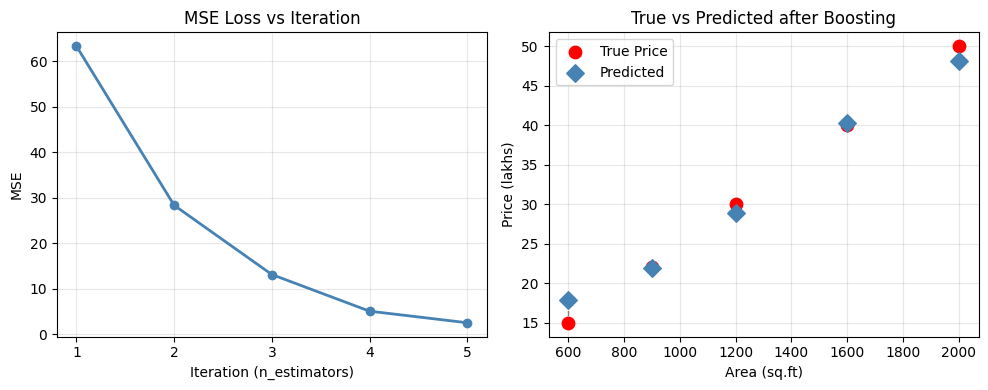

In [15]:
# Visualize loss going down
plt.figure(figsize=(10, 4))

plt.subplot(1,2,1)
plt.plot(range(1, n_estimators+1), loss_history, 'o-', color='steelblue', lw=2)
plt.title('MSE Loss vs Iteration')
plt.xlabel('Iteration (n_estimators)')
plt.ylabel('MSE')
plt.xticks(range(1, n_estimators+1))
plt.grid(True, alpha=0.3)

plt.subplot(1,2,2)
plt.scatter(X.ravel(), y, color='red', zorder=5, label='True Price', s=80)
plt.scatter(X.ravel(), F, color='steelblue', zorder=5, label='Predicted', s=80, marker='D')
for i, (xi, yi, fi) in enumerate(zip(X.ravel(), y, F)):
    plt.plot([xi, xi], [yi, fi], 'gray', lw=1, ls='--')
plt.xlabel('Area (sq.ft)')
plt.ylabel('Price (lakhs)')
plt.title('True vs Predicted after Boosting')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Part 8 — Custom Class: `GradientBoostingRegressor` from Scratch

Ab yahi loop ek proper Python class mein likhte hain.

### Architecture:
```
__init__  → parameters store karo
fit       → training loop (residuals → tree → update)
predict   → F0 + sum of (lr * tree.predict) for all trees
```


In [16]:
class MyGradientBoostingRegressor:
    """
    Gradient Boosting Regressor from scratch using MSE loss.
    
    Parameters:
    -----------
    n_estimators : int   - number of trees to build
    learning_rate: float - shrinkage factor (eta)
    max_depth    : int   - max depth of each weak learner tree
    """
    
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3):
        self.n_estimators  = n_estimators
        self.learning_rate = learning_rate
        self.max_depth     = max_depth
        self.trees         = []           # store all trained trees
        self.F0            = None         # initial prediction (mean)
        self.loss_history  = []           # MSE at each step
    
    def fit(self, X, y):
        # ── Step 0: Initialize with mean ──────────────────────────
        self.F0 = y.mean()
        F = np.full(len(y), self.F0, dtype=float)
        
        # ── Sequential boosting loop ───────────────────────────────
        for m in range(self.n_estimators):
            
            # Step A: Pseudo-residuals (negative gradient of MSE)
            r = y - F                           # r_i = y_i - F_i
            
            # Step B: Fit weak learner to residuals
            tree = DecisionTreeRegressor(
                max_depth=self.max_depth, 
                random_state=42
            )
            tree.fit(X, r)
            self.trees.append(tree)
            
            # Step C: Update predictions with shrinkage
            F = F + self.learning_rate * tree.predict(X)
            
            # Record training loss
            self.loss_history.append(np.mean((y - F)**2))
        
        return self
    
    def predict(self, X):
        # Start from base prediction
        F = np.full(X.shape[0], self.F0, dtype=float)
        
        # Add contribution of each tree
        for tree in self.trees:
            F = F + self.learning_rate * tree.predict(X)
        
        return F

print("Class defined successfully!")
print("Methods: fit(X, y), predict(X)")


Class defined successfully!
Methods: fit(X, y), predict(X)


In [17]:
# Test our custom implementation
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor as SklearnGBR
from sklearn.metrics import mean_squared_error

# Generate a synthetic dataset
X_data, y_data = make_regression(n_samples=300, n_features=5, noise=10, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

# Our model
my_gbr = MyGradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3)
my_gbr.fit(X_tr, y_tr)
my_pred = my_gbr.predict(X_te)

# Sklearn model (for comparison)
sk_gbr = SklearnGBR(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
sk_gbr.fit(X_tr, y_tr)
sk_pred = sk_gbr.predict(X_te)

print("=== Regression Results ===")
print(f"My GBR  MSE : {mean_squared_error(y_te, my_pred):.4f}")
print(f"Sklearn MSE : {mean_squared_error(y_te, sk_pred):.4f}")
print()
print("(Both should be close — small diff due to sklearn's internal optimizations)")


=== Regression Results ===
My GBR  MSE : 420.9885
Sklearn MSE : 412.1995

(Both should be close — small diff due to sklearn's internal optimizations)


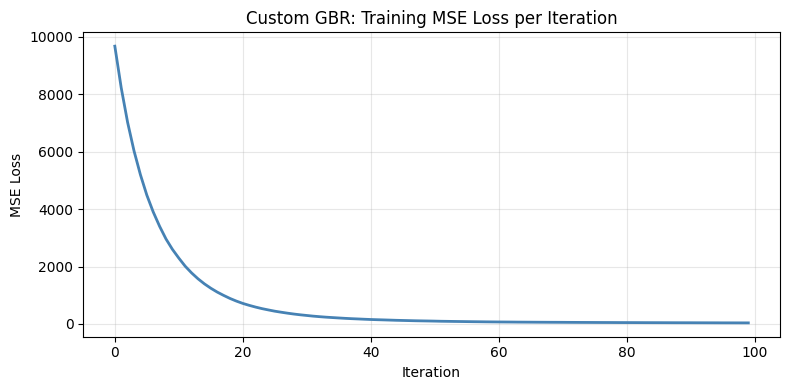

In [18]:
# Plot: Loss curve of our custom model
plt.figure(figsize=(8, 4))
plt.plot(my_gbr.loss_history, color='steelblue', lw=2)
plt.title('Custom GBR: Training MSE Loss per Iteration')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## Part 9 — Classification ke liye Gradient Boosting

Regression mein:
- Target = continuous number (price)
- Prediction = F directly
- Residual = y - F

Classification mein (binary):
- Target = 0 ya 1 (spam / not spam)
- Prediction = **probability** (0 se 1 ke beech)
- Hum **log-odds** F mein kaam karte hain, probability ke liye **sigmoid** lagate hain

---

### Log-Odds Kya Hota Hai?

Agar probability of spam = 0.8, toh:
$$\text{log-odds} = \ln\!\left(\frac{p}{1-p}\right) = \ln\!\left(\frac{0.8}{0.2}\right) = \ln(4) \approx 1.39$$

Aur ulti taraf — log-odds se probability:
$$p = \sigma(F) = \frac{1}{1 + e^{-F}}$$

Yeh **sigmoid function** hai. Koi bhi real number → 0 se 1 ke beech.

| Log-odds (F) | Probability (p) | Matlab |
|:-----------:|:---------------:|--------|
| -3          | 0.047           | Almost certainly 0 |
| -1          | 0.269           | Probably 0 |
| 0           | 0.500           | 50-50 |
| +1          | 0.731           | Probably 1 |
| +3          | 0.953           | Almost certainly 1 |


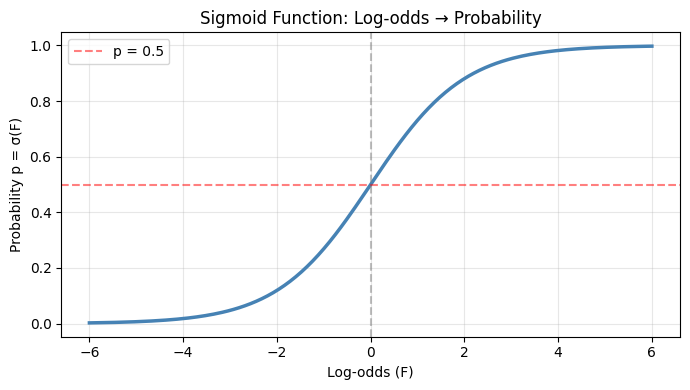

In [19]:
# Visualize sigmoid function
F_vals = np.linspace(-6, 6, 200)
p_vals = 1 / (1 + np.exp(-F_vals))

plt.figure(figsize=(7, 4))
plt.plot(F_vals, p_vals, 'steelblue', lw=2.5)
plt.axhline(0.5, color='red', ls='--', alpha=0.5, label='p = 0.5')
plt.axvline(0, color='gray', ls='--', alpha=0.5)
plt.xlabel('Log-odds (F)')
plt.ylabel('Probability p = σ(F)')
plt.title('Sigmoid Function: Log-odds → Probability')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Part 10 — Classification Residuals: y - p

### Binary Cross-Entropy (LogLoss):

$$L(y_i, F_i) = -\left[y_i \ln(p_i) + (1-y_i)\ln(1-p_i)\right]$$

### Gradient nikaalte hain (Chain Rule):

**Step 1:** $\frac{\partial L}{\partial p_i}$:
$$= -\frac{y_i}{p_i} + \frac{1-y_i}{1-p_i} = \frac{p_i - y_i}{p_i(1-p_i)}$$

**Step 2:** Sigmoid ka derivative:
$$\frac{\partial p_i}{\partial F_i} = p_i(1 - p_i)$$

**Step 3:** Chain rule:
$$\frac{\partial L}{\partial F_i} = \frac{p_i - y_i}{p_i(1-p_i)} \times p_i(1-p_i) = p_i - y_i$$

**Pseudo-residual (negative gradient):**
$$r_i = -(p_i - y_i) = y_i - p_i$$

> **Ek hi formula! Regression ki tarah hi: actual - predicted.**  
> Fark sirf yeh hai — classification mein predicted = probability $p$, regression mein predicted = raw $F$.


In [20]:
# Demo: residuals for a sample classification case
import numpy as np

y_cls = np.array([0, 0, 0, 1, 1, 1], dtype=float)
p_init = np.full(6, 0.5)   # initial probability = 0.5 for all

r_cls = y_cls - p_init     # pseudo-residuals

df_cls = pd.DataFrame({
    'Index': range(1,7),
    'True Label (y)': y_cls.astype(int),
    'Probability (p)': p_init,
    'Pseudo-Residual r = y-p': r_cls
})
print(df_cls.to_string(index=False))
print()
print("Not-Spam (0): predicted 0.5, actual 0 → residual negative (overestimated spam prob)")
print("Spam    (1): predicted 0.5, actual 1 → residual positive (underestimated spam prob)")


 Index  True Label (y)  Probability (p)  Pseudo-Residual r = y-p
     1               0              0.5                     -0.5
     2               0              0.5                     -0.5
     3               0              0.5                     -0.5
     4               1              0.5                      0.5
     5               1              0.5                      0.5
     6               1              0.5                      0.5

Not-Spam (0): predicted 0.5, actual 0 → residual negative (overestimated spam prob)
Spam    (1): predicted 0.5, actual 1 → residual positive (underestimated spam prob)


## Part 11 — Newton-Raphson Leaf Correction (Classification only)

### Problem:
Regression mein tree ka mean leaf output directly use ho jata tha. Classification mein **directly use nahi kar sakte**.

Kyun? Kyunki log-odds (F) aur probability (p) ka relation sigmoid ke through hai — yeh **non-linear** hai.

Agar hum directly tree ke leaf mean use karein, toh prediction suboptimal rahegi.

### Solution — Second-Order Taylor Expansion:

Loss function ko aur accurately minimize karne ke liye, leaf value $\gamma$ is formula se nikalte hain:

$$\gamma_j = \frac{\sum_{i \in \text{leaf}_j} r_i}{\sum_{i \in \text{leaf}_j} p_i(1-p_i)}$$

- **Numerator** = leaf mein pseudo-residuals ka sum
- **Denominator** = leaf mein Hessian weights ka sum ($p_i(1-p_i)$)

### Number Example:

Maan lo Leaf A mein index 1,2,3 hain (not spam), sab p = 0.5:
- Residuals: -0.5, -0.5, -0.5 → numerator = -1.5
- Hessians: 0.5×0.5, 0.5×0.5, 0.5×0.5 → denominator = 0.75
- $\gamma_A = -1.5 / 0.75 = -2.0$

Leaf B mein index 4,5,6 hain (spam), sab p = 0.5:
- Residuals: +0.5, +0.5, +0.5 → numerator = +1.5
- Hessians: 0.25+0.25+0.25 = 0.75
- $\gamma_B = 1.5 / 0.75 = +2.0$

### Kyun Regression Mein Nahi Chahiye?

MSE ka Hessian (second derivative w.r.t. F) = **1** (constant, har sample ke liye same).  
Toh formula ban jaata hai: $\gamma = \frac{\sum r_i}{\sum 1} = \text{mean}(r_i)$  
Jo tree already apne leaf mean ke roop mein compute karta hai — isliye no extra step needed!


In [21]:
# Newton-Raphson correction — step by step with numbers
y_demo = np.array([0, 0, 0, 1, 1, 1], dtype=float)
F_demo = np.zeros(6)                      # log-odds = 0
p_demo = 1 / (1 + np.exp(-F_demo))       # sigmoid → all 0.5
r_demo = y_demo - p_demo                  # residuals

# Fake tree: leaf A = samples 0,1,2 | leaf B = samples 3,4,5
leaf_ids = np.array([0, 0, 0, 1, 1, 1])

print("=== Newton-Raphson Leaf Correction ===\n")

gamma_dict = {}
for leaf in [0, 1]:
    mask = (leaf_ids == leaf)
    num = r_demo[mask].sum()
    den = (p_demo[mask] * (1 - p_demo[mask])).sum()
    gamma = num / (den + 1e-8)
    gamma_dict[leaf] = gamma
    label = "A (Not Spam)" if leaf == 0 else "B (Spam)"
    print(f"Leaf {label}:")
    print(f"  Residuals  : {r_demo[mask]}")
    print(f"  Numerator  : {num}")
    print(f"  Hessians   : {(p_demo[mask]*(1-p_demo[mask])).round(4)}")
    print(f"  Denominator: {den}")
    print(f"  gamma      : {num:.2f} / {den:.2f} = {gamma:.4f}")
    print()

# Build update vector
lr_demo = 0.5
update = np.array([gamma_dict[l] for l in leaf_ids])
F_new_demo = F_demo + lr_demo * update
p_new_demo = 1 / (1 + np.exp(-F_new_demo))

print("=== After Update ===")
df_update = pd.DataFrame({
    'y': y_demo.astype(int),
    'F_old': F_demo,
    'γ (leaf val)': update,
    'F_new': F_new_demo.round(3),
    'p_old': p_demo.round(3),
    'p_new': p_new_demo.round(3),
    'Better?': ['✓' if abs(y_demo[i]-p_new_demo[i]) < abs(y_demo[i]-p_demo[i]) else '✗' for i in range(6)]
})
print(df_update.to_string(index=False))


=== Newton-Raphson Leaf Correction ===

Leaf A (Not Spam):
  Residuals  : [-0.5 -0.5 -0.5]
  Numerator  : -1.5
  Hessians   : [0.25 0.25 0.25]
  Denominator: 0.75
  gamma      : -1.50 / 0.75 = -2.0000

Leaf B (Spam):
  Residuals  : [0.5 0.5 0.5]
  Numerator  : 1.5
  Hessians   : [0.25 0.25 0.25]
  Denominator: 0.75
  gamma      : 1.50 / 0.75 = 2.0000

=== After Update ===
 y  F_old  γ (leaf val)  F_new  p_old  p_new Better?
 0    0.0          -2.0   -1.0    0.5  0.269       ✓
 0    0.0          -2.0   -1.0    0.5  0.269       ✓
 0    0.0          -2.0   -1.0    0.5  0.269       ✓
 1    0.0           2.0    1.0    0.5  0.731       ✓
 1    0.0           2.0    1.0    0.5  0.731       ✓
 1    0.0           2.0    1.0    0.5  0.731       ✓


## Part 12 — Custom Class: `GradientBoostingClassifier` from Scratch


In [22]:
class MyGradientBoostingClassifier:
    """
    Gradient Boosting Classifier from scratch using LogLoss.
    Internally works in log-odds space. Uses Newton-Raphson leaf correction.
    
    Parameters:
    -----------
    n_estimators : int   - number of trees
    learning_rate: float - shrinkage (eta)
    max_depth    : int   - max depth of weak learner
    """
    
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3):
        self.n_estimators  = n_estimators
        self.learning_rate = learning_rate
        self.max_depth     = max_depth
        self.trees         = []
        self.leaf_gammas   = []     # Newton-Raphson leaf values per tree
        self.F0            = None   # initial log-odds
        self.loss_history  = []
    
    def _sigmoid(self, z):
        """Sigmoid: log-odds → probability. Clipped to avoid overflow."""
        return 1.0 / (1.0 + np.exp(-np.clip(z, -20, 20)))
    
    def _logloss(self, y, p):
        p = np.clip(p, 1e-8, 1 - 1e-8)
        return -np.mean(y * np.log(p) + (1-y) * np.log(1-p))
    
    def fit(self, X, y):
        # ── Step 0: Initialize log-odds ──────────────────────────
        p_mean = y.mean()
        self.F0 = np.log(p_mean / (1 - p_mean + 1e-8))
        F = np.full(len(y), self.F0, dtype=float)
        
        # ── Sequential loop ───────────────────────────────────────
        for m in range(self.n_estimators):
            
            # Step A: Probabilities from current log-odds
            p = self._sigmoid(F)
            
            # Step B: Pseudo-residuals
            r = y - p
            
            # Step C: Fit weak learner to residuals
            tree = DecisionTreeRegressor(
                max_depth=self.max_depth,
                random_state=42
            )
            tree.fit(X, r)
            
            # Step D: Newton-Raphson leaf correction
            leaf_ids = tree.apply(X)           # leaf index for each sample
            gamma_dict = {}
            for leaf in np.unique(leaf_ids):
                mask = (leaf_ids == leaf)
                num  = r[mask].sum()
                den  = (p[mask] * (1 - p[mask])).sum()
                gamma_dict[leaf] = num / (den + 1e-8)
            
            # Build update vector from gamma_dict
            update = np.array([gamma_dict[l] for l in leaf_ids])
            
            # Step E: Update log-odds
            F = F + self.learning_rate * update
            
            # Save
            self.trees.append(tree)
            self.leaf_gammas.append(gamma_dict)
            self.loss_history.append(self._logloss(y, self._sigmoid(F)))
        
        return self
    
    def predict_proba(self, X):
        F = np.full(X.shape[0], self.F0, dtype=float)
        for tree, gamma_dict in zip(self.trees, self.leaf_gammas):
            leaf_ids = tree.apply(X)
            # For unseen leaves (test data), default to 0
            update = np.array([gamma_dict.get(l, 0.0) for l in leaf_ids])
            F = F + self.learning_rate * update
        p = self._sigmoid(F)
        return np.column_stack([1 - p, p])
    
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

print("MyGradientBoostingClassifier defined!")


MyGradientBoostingClassifier defined!


In [23]:
# Test our classifier
from sklearn.datasets import make_classification
from sklearn.ensemble import GradientBoostingClassifier as SklearnGBC
from sklearn.metrics import accuracy_score, log_loss

X_cls, y_cls = make_classification(
    n_samples=400, n_features=6, n_classes=2, random_state=42
)
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)

# Our model
my_gbc = MyGradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3)
my_gbc.fit(X_tr_c, y_tr_c.astype(float))
my_acc = accuracy_score(y_te_c, my_gbc.predict(X_te_c))

# Sklearn
sk_gbc = SklearnGBC(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
sk_gbc.fit(X_tr_c, y_tr_c)
sk_acc = accuracy_score(y_te_c, sk_gbc.predict(X_te_c))

print("=== Classification Results ===")
print(f"My GBC  Accuracy : {my_acc:.4f}")
print(f"Sklearn Accuracy : {sk_acc:.4f}")


=== Classification Results ===
My GBC  Accuracy : 0.9750
Sklearn Accuracy : 0.9750


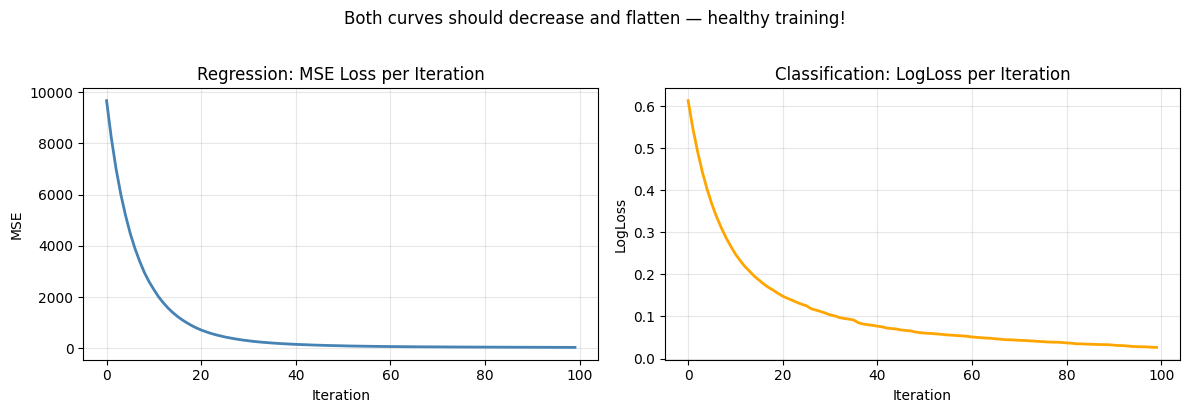

In [24]:
# Loss curves — both models side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(my_gbr.loss_history, color='steelblue', lw=2)
axes[0].set_title('Regression: MSE Loss per Iteration')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('MSE')
axes[0].grid(True, alpha=0.3)

axes[1].plot(my_gbc.loss_history, color='orange', lw=2)
axes[1].set_title('Classification: LogLoss per Iteration')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('LogLoss')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Both curves should decrease and flatten — healthy training!', y=1.02)
plt.tight_layout()
plt.show()


## Part 13 — Hyperparameters ka Effect

Teen important hyperparameters hain:

| Parameter | Effect |
|-----------|--------|
| `n_estimators` | Zyada trees → bias kam → overfitting risk zyada |
| `learning_rate` | Chhota lr → dheere seekhna → zyada trees chahiye |
| `max_depth` | Gehri tree → complex patterns → overfitting risk |

**Classic trade-off:**  
`learning_rate=0.1, n_estimators=100` ≈ `learning_rate=0.01, n_estimators=1000`  
(Lekin small lr + many trees almost hamesha win karta hai, at cost of training time)


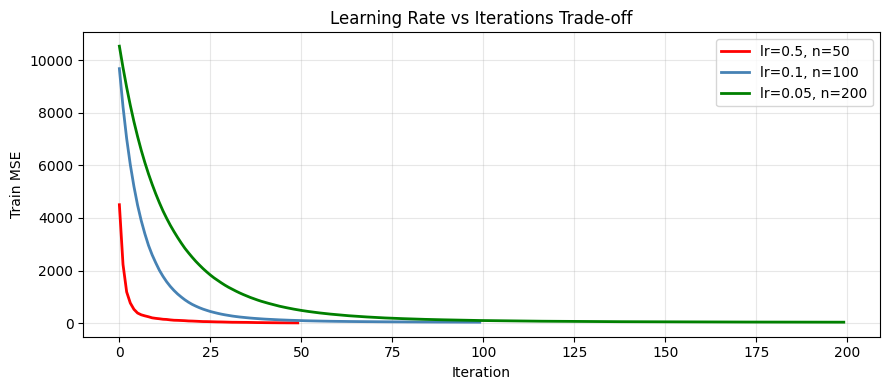

All three converge to similar loss — smaller lr just needs more iterations.


In [25]:
# Experiment: different learning rates
configs = [
    {'lr': 0.5, 'n': 50,  'color': 'red',       'label': 'lr=0.5, n=50'},
    {'lr': 0.1, 'n': 100, 'color': 'steelblue',  'label': 'lr=0.1, n=100'},
    {'lr': 0.05,'n': 200, 'color': 'green',      'label': 'lr=0.05, n=200'},
]

plt.figure(figsize=(9, 4))
for cfg in configs:
    m = MyGradientBoostingRegressor(
        n_estimators=cfg['n'], 
        learning_rate=cfg['lr'], 
        max_depth=3
    )
    m.fit(X_tr, y_tr)
    plt.plot(m.loss_history, color=cfg['color'], lw=2, label=cfg['label'])

plt.xlabel('Iteration')
plt.ylabel('Train MSE')
plt.title('Learning Rate vs Iterations Trade-off')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("All three converge to similar loss — smaller lr just needs more iterations.")


---
## Part 14 — Complete Summary

### Gradient Boosting Algorithm:

```
Input: Dataset (X, y), n_estimators M, learning_rate η, max_depth d

1. F₀ = constant_init(y)
   • Regression:     F₀ = mean(y)
   • Classification: F₀ = log(mean(y) / (1 - mean(y)))

2. For m = 1 to M:
   a. Compute pseudo-residuals:
      • Regression:     r_i = y_i - F_i
      • Classification: r_i = y_i - sigmoid(F_i)
   
   b. Fit weak learner h_m to (X, r)
   
   c. Compute leaf update values:
      • Regression:     use tree's own leaf mean
      • Classification: γ_j = Σ(r_i) / Σ(p_i(1-p_i))  for each leaf j
   
   d. Update predictions:
      F_m = F_{m-1} + η × h_m(x)

3. Final prediction:
   • Regression:     ŷ = F_M
   • Classification: p = sigmoid(F_M), class = (p >= 0.5)
```

---

### Key Formulas:

| Concept | Formula |
|---------|---------|
| Additive model | $F_M(x) = F_0 + \sum_{m=1}^{M} \eta \cdot h_m(x)$ |
| MSE pseudo-residual | $r_i = y_i - F_i$ |
| LogLoss pseudo-residual | $r_i = y_i - \sigma(F_i)$ |
| Sigmoid | $\sigma(z) = \frac{1}{1+e^{-z}}$ |
| Newton-Raphson leaf | $\gamma_j = \frac{\sum r_i}{\sum p_i(1-p_i)}$ |
| Log-odds init | $F_0 = \ln\left(\frac{\bar{y}}{1-\bar{y}}\right)$ |

---

### Interview Mein Pooche Jaane Wale Questions:

1. **Pseudo-residual kya hai?** → Current prediction ka negative gradient — kitna aur kahan galat hain
2. **Gradient Descent se kaise connected hai?** → Parameters update karne ki jagah, predictions update karte hain (function space GD)
3. **Learning rate kyun?** → Shrinkage — har step chhota le, overfitting se bacho
4. **Newton-Raphson classification mein kyun?** → LogLoss ka Hessian p(1-p) vary karta hai — simple mean optimal nahi
5. **AdaBoost vs GBM?** → AdaBoost: sample weights badhaata hai. GBM: residuals pe tree fit karta hai
